# Базовое решение Задачи "Разработка нефтегазовых месторождений"

Набор данных содержит 442 о различных нефтегазовых месторождениях.
Тренировочный набор - 309 строк.
Тестовый набор - 133 строк.

Каждое месторождение обладает 19 параметрами:
1. Field name - название месторождения
2. Reservoir unit - юнит месторождения
3. Country - страна расположения
4. Region - регион расположения
5. Basin name - название бассейна пород
6. Tectonic regime - тектонический режим
7. Latitude - широта
8. Longitude - долгота
9. Operator company - название компании
10. Onshore or oﬀshore - на суше или нет
11. Hydrocarbon type (main) - тип углеводорода
12. Reservoir status (current) - статус месторождения
13. Structural setting - структурные свойства
14. Depth (top reservoir ft TVD) - глубина
15. Reservoir period - литологический период
16. Lithology (main) - литология
17. Thickness (gross average ft) - общая толщина
18. Thickness (net pay average ft) - эффективная толщина
19. Porosity (matrix average 20. Permeability (air average mD) – проницаемость

## Считывание данных

In [1]:
# Установим библиотеку для работы с датасетами на kaggle
!pip install opendatasets --quiet

In [42]:
import opendatasets as od

# Загрузим датасет на прямую с kaggle
dataset_url = 'https://www.kaggle.com/competitions/classification-of-oil-and-gas/data'
# {"username":"adele1997","key":"b359174f8c6e8efc9d9869284646ee1e"}
# Upload Kaggle.json file to Colab… (Caution: Do not Share kaggle.json as contains API key of your Kaggle Account)

od.download(dataset_url)

Skipping, found downloaded files in "./classification-of-oil-and-gas" (use force=True to force download)


In [45]:
# иморитирование всех необходимых библиотек
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
# Считываем тренировочные данные
train = pd.read_csv("./classification-of-oil-and-gas/train_oil.csv")
test = pd.read_csv("./classification-of-oil-and-gas/oil_test.csv")

print(f"Train dataset shape: {train.shape}")
print(f"Test dataset shape: {test.shape}")

Train dataset shape: (309, 20)
Test dataset shape: (133, 19)


In [47]:
# Посмотрим как выглядят данные
train.head()

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,53.2287,-115.8008,NUMEROUS,ONSHORE,OIL,UNKNOWN,FORELAND,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0


## Исследование и обработка данных

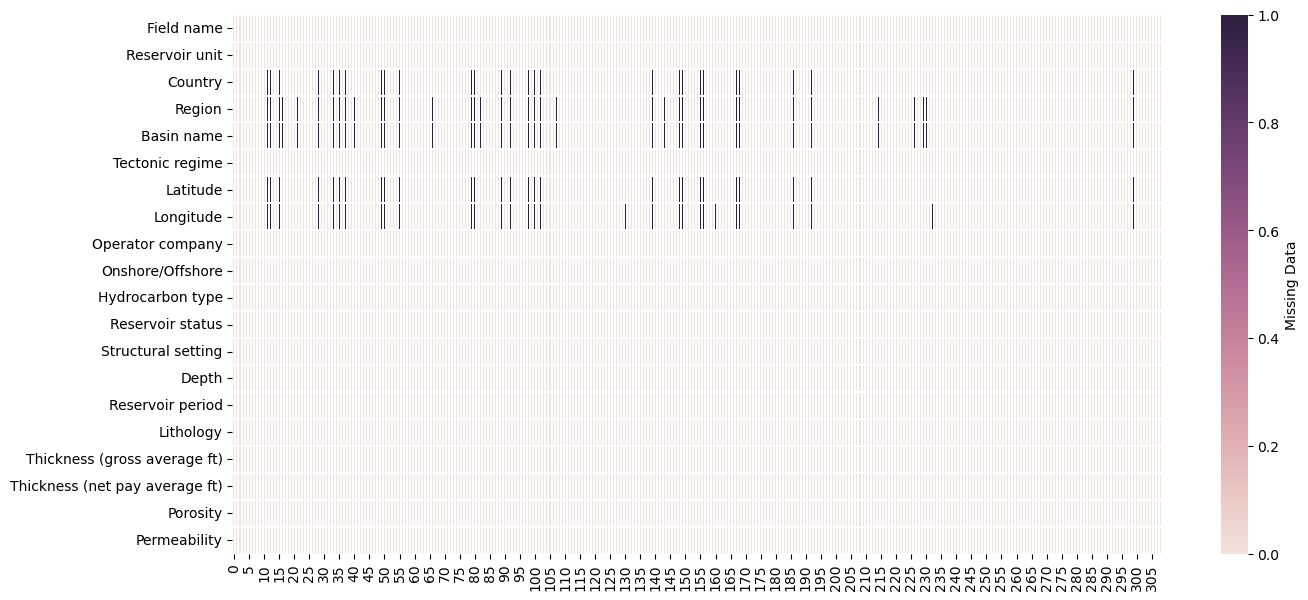

In [11]:
plt.figure(figsize=(15,7))

cmap = sns.cubehelix_palette(as_cmap=True, light=.9)

sns.heatmap(train.isna().transpose(), cmap=cmap,
            cbar_kws={'label': 'Missing Data'}, linewidths=0.05)

plt.savefig("visualizing_missing_data_with_heatmap_Seaborn_Python.png", dpi=100)

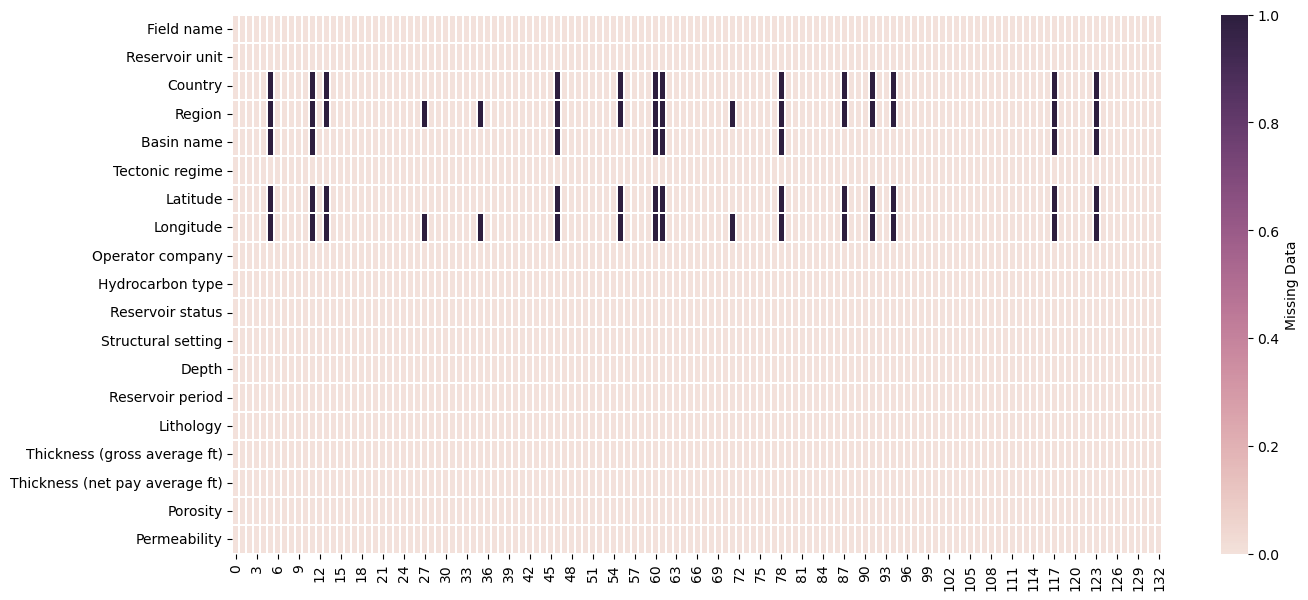

In [12]:
plt.figure(figsize=(15,7))

cmap = sns.cubehelix_palette(as_cmap=True, light=.9)

sns.heatmap(test.isna().transpose(), cmap=cmap,
            cbar_kws={'label': 'Missing Data'}, linewidths=0.05)

plt.savefig("visualizing_missing_data_with_heatmap_Seaborn_Python.png", dpi=100)

In [13]:
print(train.shape)
train = train.dropna()
print(train.shape)
# 309 - 268

(309, 20)
(268, 20)


### Обработка категориальных признаков

In [14]:
train.head()

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,53.2287,-115.8008,NUMEROUS,ONSHORE,OIL,UNKNOWN,FORELAND,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0


In [15]:
train['Tectonic regime'].value_counts()

Tectonic regime
COMPRESSION                                                 57
EXTENSION                                                   26
COMPRESSION/EROSION                                         25
COMPRESSION/EVAPORITE                                       18
INVERSION/COMPRESSION/EXTENSION                             17
EXTENSION/EROSION                                           12
GRAVITY/EXTENSION/EVAPORITE                                 10
INVERSION/COMPRESSION/EXTENSION/EROSION                      7
GRAVITY/EXTENSION/EVAPORITE/SYNSEDIMENTATION                 7
COMPRESSION/EVAPORITE/EXTENSION/LINKED                       7
INVERSION/STRIKE-SLIP/TRANSPRESSION/EXTENSION/BASEMENT-I     5
INVERSION/COMPRESSION/EXTENSION/EVAPORITE                    4
GRAVITY/EVAPORITE/EXTENSION                                  4
COMPRESSION/EXTENSION/LINKED                                 4
GRAVITY/EVAPORITE/COMPRESSION                                4
GRAVITY/EXTENSION/SHALE/SYNSEDIMENTATIO

In [16]:
train['Tectonic regime'].nunique()

54

In [17]:
# pd.get_dummies()
train['Tectonic regime'].str.get_dummies(sep='/')

# Tectonic_regime_BASEMENT-I

,BASEMENT-I,COMPRESSION,DIAPIR,EROSION,EVAPORITE,EXTENSION,GRAVITY,INVERSION,LINKED,REACTIVATION,SHALE,STRIKE-SLIP,SYNSEDIMENTATION,TRANSPRESSION,TRANSTENSION,UPLIFT
0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
305,0,1,0,0,1,1,0,0,1,0,0,0,0,0,0,0
306,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
307,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Как мы видим в колонке 'Tectonic regime' множество разных категорий, причем одному объекту может соответствовать несколько категорий сразу.

Встает вопрос как обработать такие признаки.

In [18]:
train['Structural setting'].value_counts()

Structural setting
FORELAND                      67
RIFT                          43
INTRACRATONIC                 27
THRUST                        14
PASSIVE MARGIN                12
SALT/FORELAND                 11
SALT/PASSIVE MARGIN            9
INVERSION/RIFT                 7
DELTA/PASSIVE MARGIN           7
INVERSION/BACKARC              6
DELTA/SALT/PASSIVE MARGIN      5
SALT/INVERSION/RIFT            5
THRUST/FORELAND                4
RIFT/SALT                      4
SUB-THRUST/FORELAND            4
SUB-SALT/FORELAND              3
WRENCH                         3
RIFT/INVERSION                 3
BACKARC                        3
SUB-SALT/RIFT                  3
THRUST/SUB-THRUST/FORELAND     2
SALT/RIFT                      2
SUB-THRUST                     2
FORELAND/SALT                  2
SUB-SALT/INVERSION             2
FORELAND/THRUST                2
WRENCH/DELTA                   2
WRENCH/INVERSION/BACKARC       1
WRENCH/RIFT                    1
SUB-SALT/PASSIVE MARGIN 

In [19]:
train['Basin name'].value_counts().head(50)

Basin name
WESTERN CANADA                      24
GULF OF MEXICO NORTHERN ONSHORE     19
NORTH SEA CENTRAL                   14
NORTH SEA NORTHERN                  12
WILLISTON                           10
PERMIAN                             10
BOHAI                                8
ANADARKO                             7
SIBERIAN WESTERN                     7
RUB AL KHALI                         6
POWDER RIVER                         6
THE GULF                             5
JIUQUAN                              4
PARIS                                4
GREATER GREEN RIVER                  4
MID-NORWAY SHELF                     4
CAMBAY                               4
EASTERN VENEZUELA                    4
CASPIAN SOUTH                        4
GIPPSLAND                            4
SIBERIAN EASTERN                     4
VOLGA-URAL                           3
AMU DARYA                            3
CASPIAN NORTH                        3
SUMATRA CENTRAL                      3
BIG HORN      

In [20]:
train['Operator company'].value_counts()

Operator company
NUMEROUS                        26
CHEVRON                         15
PETROCHINA                      14
SHELL                            9
BP                               9
                                ..
EXXONMOBIL /SMNG                 1
OIL SEARCH LTD                   1
PANARCTIC OILS                   1
SAMUEL GARY                      1
MATRIX PRODUCTION AND OTHERS     1
Name: count, Length: 123, dtype: int64

In [21]:
train['Region'].value_counts()

Region
NORTH AMERICA          110
FAR EAST                46
EUROPE                  38
FORMER SOVIET UNION     25
MIDDLE EAST             20
AFRICA                  17
LATIN AMERICA           12
Name: count, dtype: int64

In [22]:
train = train.drop(columns=['Tectonic regime', 'Structural setting', 'Field name', 'Reservoir unit', 'Country',
                            'Region', 'Basin name', 'Operator company'])
test = test.drop(columns=['Tectonic regime', 'Structural setting', 'Field name', 'Reservoir unit', 'Country',
                            'Region', 'Basin name', 'Operator company'])

train.head()

,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,51.0000,44.8042,ONSHORE,OIL,DECLINING PRODUCTION,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,-19.6017,-39.8332,ONSHORE,OIL,NEARLY DEPLETED,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,26.0800,49.8100,ONSHORE,OIL,REJUVENATING,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,61.3833,1.7500,OFFSHORE,OIL,NEARLY DEPLETED,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,53.2287,-115.8008,ONSHORE,OIL,UNKNOWN,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0


In [23]:
train['Hydrocarbon type'].value_counts()

Hydrocarbon type
OIL               200
GAS                40
GAS-CONDENSATE     26
CARBON DIOXIDE      2
Name: count, dtype: int64

In [24]:
train['Field name'].value_counts()

KeyError: 'Field name'

In [25]:
train['Reservoir unit'].value_counts()

KeyError: 'Reservoir unit'

In [26]:
train['Country'].value_counts()

KeyError: 'Country'

/tmp/ipykernel_378919/1311538264.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(train['Hydrocarbon type'], ax=ax[0], palette='hls')
/tmp/ipykernel_378919/1311538264.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(train['Onshore/Offshore'], ax=ax[1], palette='hls')
/tmp/ipykernel_378919/1311538264.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


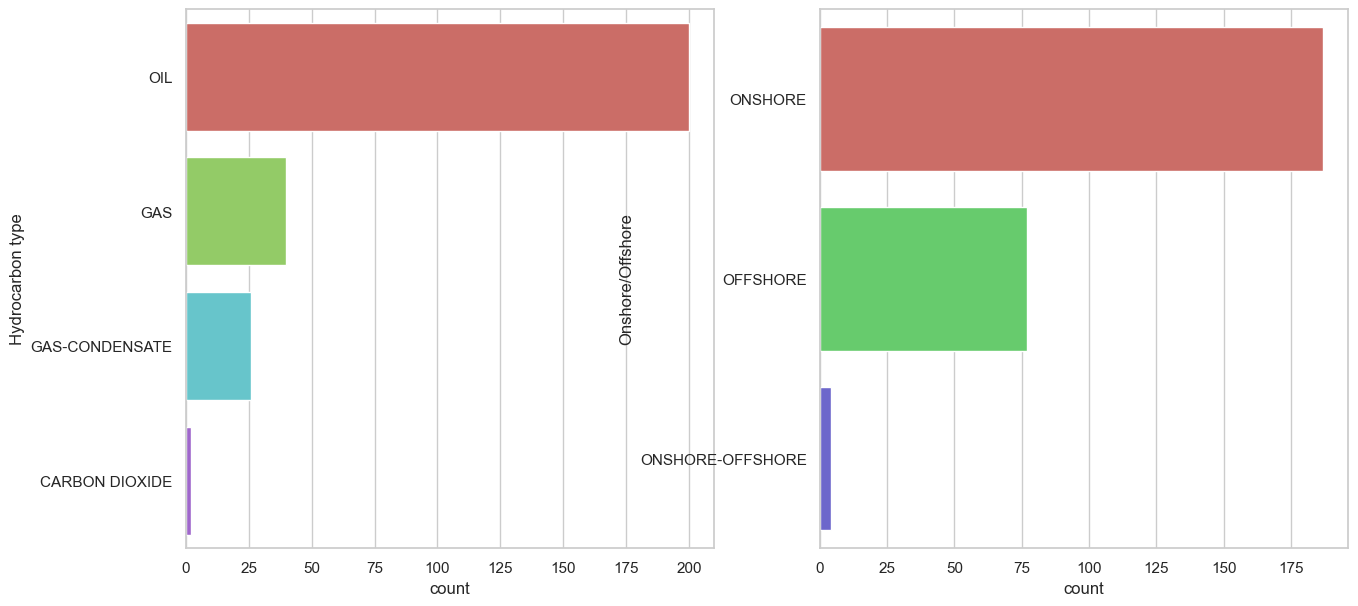

In [27]:
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)

fig, ax = plt.subplots(1,2, figsize=(15, 7))

sns.countplot(train['Hydrocarbon type'], ax=ax[0], palette='hls')
sns.countplot(train['Onshore/Offshore'], ax=ax[1], palette='hls')
fig.show()

In [28]:
train['Onshore/Offshore'].value_counts()

Onshore/Offshore
ONSHORE             187
OFFSHORE             77
ONSHORE-OFFSHORE      4
Name: count, dtype: int64

Остальные категориальные признаки устроены проще и к ним можно применить обычные методы кодирования, которые мы изучали до этого.

Применим к ним кодировщик LabelEncoder().

In [29]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=['Onshore/Offshore'])
y = train['Onshore/Offshore']

# Разбиваем данные с учетом стратификации
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 20% данных в тест
    random_state=42,         # Фиксируем для воспроизводимости
    stratify=y               # Стратифицированное разбиение
)

print(f'Train dataset size: {X_train.shape}, {y_train.shape}')
print(f'Train dataset size: {X_test.shape}, {y_test.shape}')

Train dataset size: (214, 11), (214,)
Train dataset size: (54, 11), (54,)


In [30]:
from sklearn.preprocessing import OrdinalEncoder

# Список категориальных столбцов
categ = ['Hydrocarbon type', 'Reservoir status', 'Reservoir period', 'Lithology']

# Создаем OrdinalEncoder, обрабатываем неизвестные категории специальным значением -1
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

train_encoded = encoder.fit_transform(X_train[categ]) # numpy
test_encoded = encoder.transform(X_test[categ]) # numpy

# Заменяем старые категориальные столбцы новыми закодированными
X_train[categ] = train_encoded
X_test[categ] = test_encoded

In [31]:
X_train

,Latitude,Longitude,Hydrocarbon type,Reservoir status,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
248,70.3400,-149.5375,3.0,2.0,5620,3.0,6.0,35.0,20.0,24.0,138.0
48,55.2197,-119.1749,3.0,2.0,6125,18.0,7.0,80.0,22.0,10.2,60.0
303,32.1270,-102.6353,3.0,6.0,4185,16.0,3.0,350.0,40.0,8.0,3.0
288,5.6284,114.8906,3.0,2.0,1180,11.0,7.0,6739.0,500.0,23.0,250.0
287,23.5310,53.2953,3.0,9.0,7650,3.0,5.0,420.0,290.0,23.0,20.0
...,...,...,...,...,...,...,...,...,...,...,...
154,47.2376,-103.5028,3.0,2.0,9125,1.0,3.0,105.0,40.0,16.0,25.0
211,44.1497,-105.1171,3.0,5.0,8278,16.0,7.0,100.0,37.0,12.0,50.0
187,57.4375,107.3058,2.0,4.0,8596,17.0,7.0,172.0,25.0,9.0,152.0
244,61.1300,70.4600,3.0,1.0,7677,3.0,7.0,1300.0,140.0,19.0,3.6


In [32]:
y_train

248     ONSHORE
48      ONSHORE
303     ONSHORE
288    OFFSHORE
287     ONSHORE
         ...   
154     ONSHORE
211     ONSHORE
187     ONSHORE
244     ONSHORE
65      ONSHORE
Name: Onshore/Offshore, Length: 214, dtype: str

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

y_train

array([1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 2,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Heatmap позволяет визуадизировать матрицу корреляции между данными.

Корреляция - важнейший фактор, лежащий в основе анализа данных. Он сообщает, как переменные в наборе данных связаны друг с другом и как они перемещаются относительно друг друга. Значение корреляции колеблется от -1 до +1. 0 Корреляция означает, что две переменные не зависят друг от друга. Положительная корреляция указывает на то, что переменные движутся в одном направлении, а отрицательная корреляция указывает на противоположное.

In [34]:
tmp = pd.concat([X_train.reset_index(), pd.DataFrame(y_train)], axis=1)

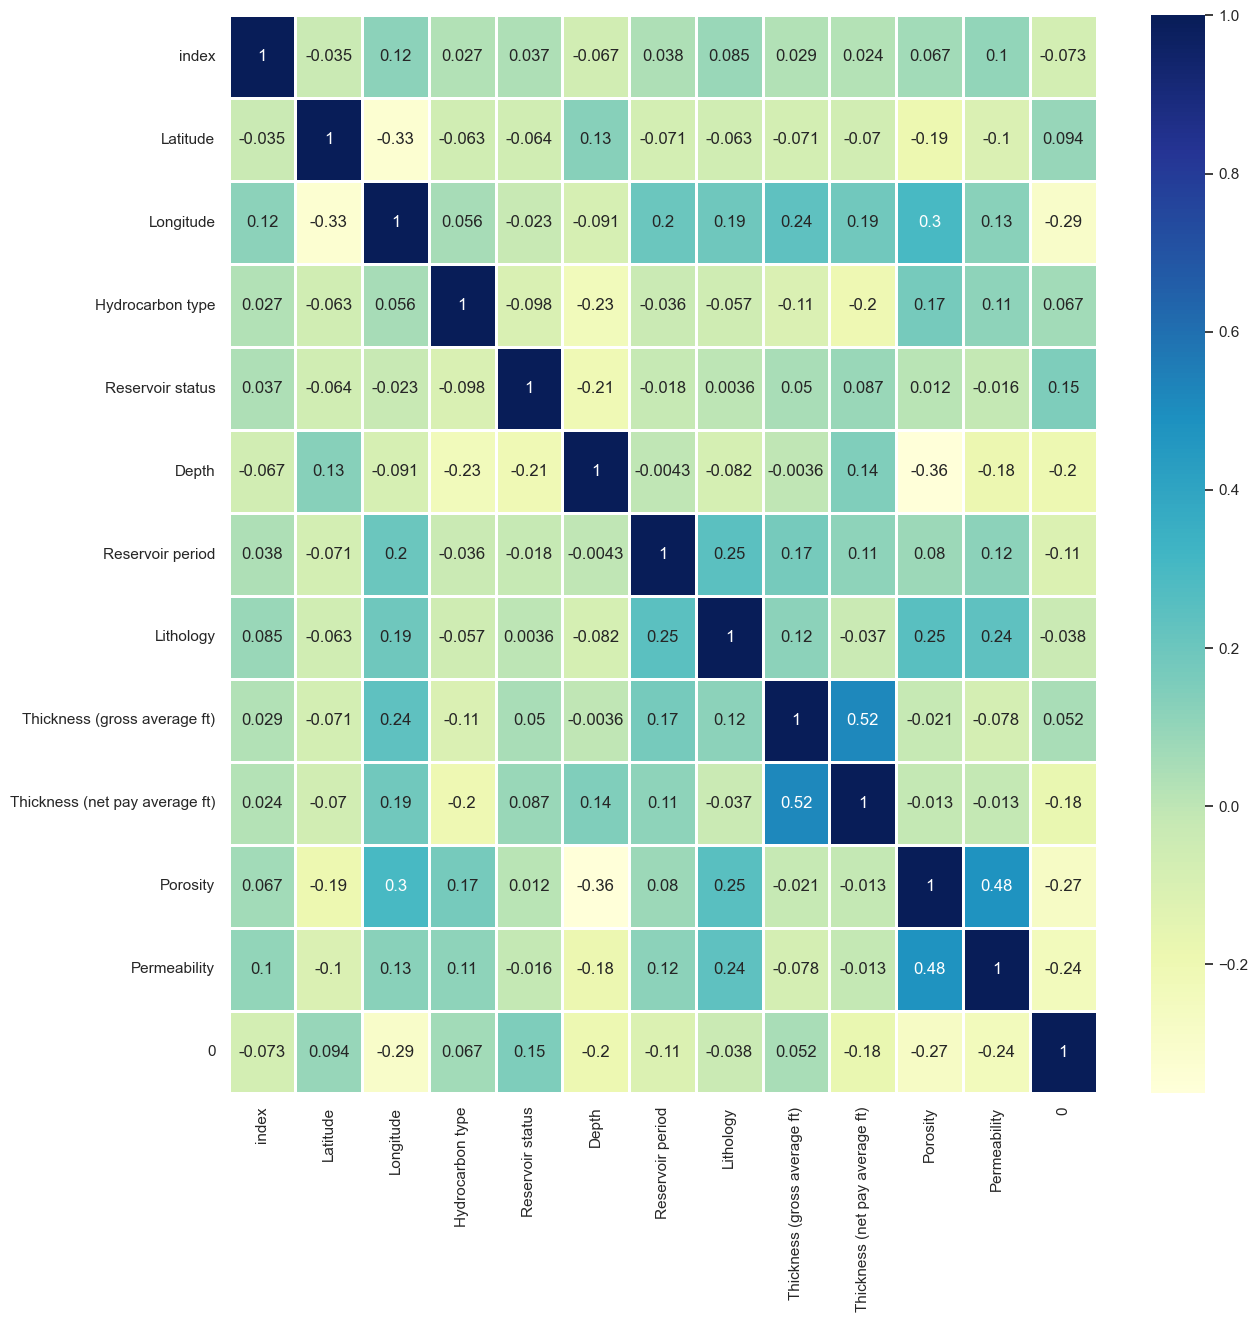

In [35]:
sns.set(rc = {'figure.figsize':(14, 14)})

sns.heatmap(tmp.corr(), annot = True, cmap="YlGnBu", linecolor='white',linewidths=1)

plt.savefig("heatmap.png")

In [36]:
train.corr(numeric_only=True)

,Latitude,Longitude,Depth,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
Latitude,1.000000,-0.323678,0.133160,-0.065420,-0.056571,-0.181211,-0.147912
Longitude,-0.323678,1.000000,-0.100164,0.217488,0.162770,0.270450,0.150411
Depth,0.133160,-0.100164,1.000000,0.018561,0.174854,-0.380279,-0.216259
Thickness (gross average ft),-0.065420,0.217488,0.018561,1.000000,0.501022,-0.037438,-0.091668
Thickness (net pay average ft),-0.056571,0.162770,0.174854,0.501022,1.000000,-0.061748,-0.051282
Porosity,-0.181211,0.270450,-0.380279,-0.037438,-0.061748,1.000000,0.484160
Permeability,-0.147912,0.150411,-0.216259,-0.091668,-0.051282,0.484160,1.000000


По сути, это сетка цветных квадратов , где каждый квадрат, или bin , отмечает пересечение значений двух переменных, которые простираются вдоль горизонтальной и вертикальной осей.

Цветовые палитры: https://seaborn.pydata.org/tutorial/color_palettes.html

Информация о HeatMap: https://seaborn.pydata.org/generated/seaborn.heatmap.html


In [37]:
# train_X.columns
# test_X.columns

# len(set(train_X.columns) & set(test_X.columns)) == len(train_X.columns)

In [38]:
# sns.set()
# columns = ['Onshore/Offshore', 'Reservoir status', 'Depth', 'Lithology_CHALK', 'Reservoir period_CRETACEOUS-PALEOGENE',
#            'Thickness (gross average ft)', 'Thickness (net pay average ft)', 'Porosity', 'Permeability', 'Region', 'Latitude', 'Longitude']

# sns.pairplot(train[columns], size = 4, kind ='scatter', diag_kind='kde')
# plt.show()

# plt.savefig("pairplot.png")

In [39]:
# sns.set()
# columns = ['Region', 'Latitude', 'Longitude']

# sns.pairplot(train[columns], kind ='scatter', diag_kind='kde')
# plt.show()

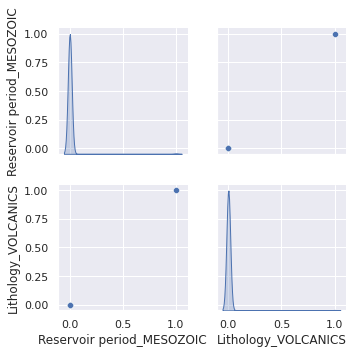

In [ ]:
# sns.set()
# columns = ['Reservoir period_MESOZOIC', 'Lithology_VOLCANICS']

# sns.pairplot(train[columns], kind ='scatter', diag_kind='kde')
# plt.show()

Посмотрим на баланс классов.

/tmp/ipykernel_378919/2665399700.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Onshore/Offshore', data=y_data, palette='hls')


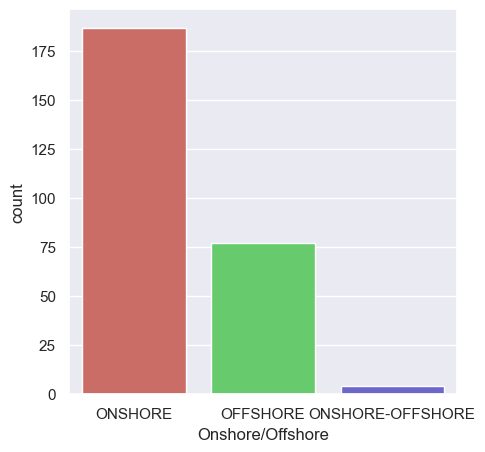

In [40]:
sns.set(rc = {'figure.figsize':(5,5)})
y_data = pd.DataFrame(train['Onshore/Offshore'])
sns.countplot(x='Onshore/Offshore', data=y_data, palette='hls')
plt.show()

In [41]:
train['Onshore/Offshore'].value_counts()

Onshore/Offshore
ONSHORE             187
OFFSHORE             77
ONSHORE-OFFSHORE      4
Name: count, dtype: int64

In [ ]:
# train.head()

,Field name,Reservoir unit,Country,Region,Basin name,Latitude,Longitude,Operator company,Onshore/Offshore,Reservoir status,...,Lithology_DOLOMITE,Lithology_DOLOMITIC LIMESTONE,Lithology_LIMESTONE,Lithology_LOW-RESISTIVITY SANDSTONE,Lithology_SANDSTONE,Lithology_SHALE,Lithology_SHALY SANDSTONE,Lithology_SILTSTONE,Lithology_THINLY-BEDDED SANDSTONE,Lithology_VOLCANICS
0,ZHIRNOV,MELEKESKIAN,RUSSIA,3,VOLGA-URAL,51.0000,44.8042,NIZHNEVOLZHSKNET,1,2,...,0,0,0,0,1,0,0,0,0,0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,4,ESPIRITO SANTO,-19.6017,-39.8332,PETROBRAS,1,6,...,0,0,0,0,1,0,0,0,0,0
2,ABQAIQ,ARAB D,SAUDI ARABIA,5,THE GULF,26.0800,49.8100,SAUDI ARAMCO,1,8,...,0,0,1,0,0,0,0,0,0,0
3,MURCHISON,BRENT,UK /NORWAY,1,NORTH SEA NORTHERN,61.3833,1.7500,CNR,0,6,...,0,0,0,0,1,0,0,0,0,0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,6,WESTERN CANADA,53.2287,-115.8008,NUMEROUS,1,12,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
train = train.drop(columns=['Field name','Reservoir unit', 'Country','Basin name', 'Operator company'])

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 268 entries, 0 to 308
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Latitude                        268 non-null    float64
 1   Longitude                       268 non-null    float64
 2   Onshore/Offshore                268 non-null    int64  
 3   Hydrocarbon type                268 non-null    float64
 4   Reservoir status                268 non-null    float64
 5   Depth                           268 non-null    int64  
 6   Reservoir period                268 non-null    float64
 7   Lithology                       268 non-null    float64
 8   Thickness (gross average ft)    268 non-null    float64
 9   Thickness (net pay average ft)  268 non-null    float64
 10  Porosity                        268 non-null    float64
 11  Permeability                    268 non-null    float64
dtypes: float64(10), int64(2)
memory usage: 27

## Обучение модели

In [37]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Создадим модель дерева решений
tree = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier(2)

# обучение модели
tree.fit(X_train, y_train)
knn.fit(X_train, y_train)

# предсказание ответов для тестовой выборки
y_pred_tree = tree.predict(X_test)
y_pred_knn = knn.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# answers_pred - ответы которые вернула модель для X_test
# y_test - это правильные ответы для X_test
print(f'Accuracy: {accuracy_score(y_test, y_pred_tree)}')
print(f'Accuracy: {accuracy_score(y_test, y_pred_knn)}')

Accuracy: 0.8148148148148148
Accuracy: 0.6111111111111112


In [ ]:
import numpy as np

np.unique(y_train)

array([0, 1, 2])

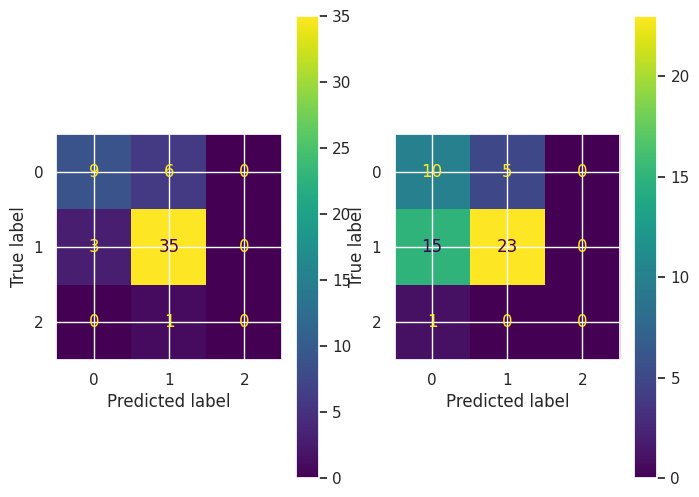

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

conf_matrix_tree = confusion_matrix(y_test, y_pred_tree)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

fig, axes = plt.subplots(1, 2, figsize=(8,6), dpi=100)

display = ConfusionMatrixDisplay(conf_matrix_tree, display_labels=tree.classes_)
display.plot(ax=axes[0])

display = ConfusionMatrixDisplay(conf_matrix_knn, display_labels=knn.classes_)
display.plot(ax=axes[1])

# Финальный сабмит

In [47]:
train = train.drop(columns=['Tectonic regime', 'Structural setting', 'Field name', 'Reservoir unit', 'Country',
                            'Region', 'Basin name', 'Operator company'])
test = test.drop(columns=['Tectonic regime', 'Structural setting', 'Field name', 'Reservoir unit', 'Country',
                            'Region', 'Basin name', 'Operator company'])

In [48]:
train.shape

(309, 12)

In [49]:
test.shape

(133, 11)

In [51]:
train = train.dropna()

In [52]:
train.shape

(279, 12)

In [56]:
test['Latitude'] = test['Latitude'].fillna(0)
test['Longitude'] = test['Longitude'].fillna(0)

In [57]:
from sklearn.preprocessing import OrdinalEncoder

# Список категориальных столбцов
categ = ['Hydrocarbon type', 'Reservoir status', 'Reservoir period', 'Lithology']

# Создаем OrdinalEncoder, обрабатываем неизвестные категории специальным значением -1
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

train_encoded = encoder.fit_transform(train[categ]) # numpy
test_encoded = encoder.transform(test[categ]) # numpy

# Заменяем старые категориальные столбцы новыми закодированными
train[categ] = train_encoded
test[categ] = test_encoded

/tmp/ipykernel_422/2678554307.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train[categ] = train_encoded


In [61]:
from sklearn.tree import DecisionTreeClassifier

# Создадим модель дерева решений
tree = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier(2)

X = train.drop(columns=['Onshore/Offshore'])
y = train['Onshore/Offshore']
y = le.fit_transform(y)

# обучение модели
tree.fit(X, y)

# предсказание ответов для тестовой выборки
y_pred_tree = tree.predict(test)

In [62]:
y_pred_tree

array([1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 2, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1,
       1])

In [63]:
ans_df = pd.DataFrame(y_pred_tree, columns=['Onshore/Offshore'])

ans_df.reset_index(inplace=True)
ans_df.to_csv('submition_all_train.csv', index=False)